In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import RepeatedKFold, cross_val_predict
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score 
from matplotlib.patches import Patch
from matplotlib.cm import coolwarm
import matplotlib.colors as mcolors
from sklearn.utils import resample
from sklearn.metrics import confusion_matrix, accuracy_score

#### **Load data**

In [2]:
file_path = "NMR Binning Data commercial honey 700MHz.xlsx - Sheet1.csv"   # <-- UPDATE THIS

# Column names
sample_col = "Primary ID"
class_col = "Type"            # second column name (Stingless bee / Honey bee)

In [3]:
df = pd.read_csv(file_path)
print(f"Loaded {df.shape[0]} samples, {df.shape[1]} columns")

Loaded 20 samples, 239 columns


In [4]:
df.head()

,Primary ID,Species,Type,9.98,9.94,9.9,9.86,9.82,9.78,9.74,...,0.93,0.89,0.85,0.81,0.77,0.73,0.69,0.65,0.61,0.57
0,C1,L. coniforn,Stingless bee,0.016182,-0.003586,0.013028,-0.004697,-0.020095,0.010307,0.001132,...,0.006444,0.017446,-0.053062,0.043035,0.000609,-7.740000e-11,-7.740000e-11,-7.740000e-11,-7.740000e-11,-7.740000e-11
1,C2,T. apicalis,Stingless bee,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,4.486630,-0.097505,0.012420,-0.045774,0.012530,5.553720e-02,-1.647710e-02,2.385090e-03,-3.439240e-02,8.802160e-03
2,C3,H. itama,Stingless bee,0.000109,0.004109,-0.001542,0.008319,-0.012011,0.001884,-0.002475,...,0.013315,-0.017879,0.019062,0.004898,-0.001811,-1.797740e-03,6.484440e-03,3.044240e-04,4.642880e-03,-1.060800e-02
3,C4,H. itama,Stingless bee,-0.009085,0.000015,0.005055,0.004618,-0.001404,0.005681,-0.008547,...,-0.075094,0.030876,0.013656,-0.008818,-0.005007,1.483650e-03,-7.099930e-03,9.060310e-03,-7.228020e-03,-1.366300e-03
4,C5,H. itama,Stingless bee,-0.011120,0.002491,-0.003872,0.002492,-0.002318,0.008324,0.006213,...,-0.052234,0.009427,-0.019906,0.016423,0.002494,5.705550e-03,-3.186350e-03,6.415300e-03,-8.370060e-03,-2.754490e-03


In [5]:
# Separate metadata and bin intensities
sample_ids = df[sample_col]
y = df[class_col]                       # class labels (string)
X = df.drop(columns=[sample_col, "Species", class_col])  # only bin columns

In [6]:
# Remove bins in the water region (4.68 – 5.03 ppm)
water_ppm_range = (4.68, 5.03)
bin_ppm = X.columns.values.astype(float)
keep_mask = (bin_ppm < water_ppm_range[0]) | (bin_ppm > water_ppm_range[1])
X = X.iloc[:, keep_mask]
print(f"Water region removed. Remaining bins: {X.shape[1]}")

Water region removed. Remaining bins: 227


In [7]:
X.head()

,9.98,9.94,9.9,9.86,9.82,9.78,9.74,9.7,9.66,9.62,...,0.93,0.89,0.85,0.81,0.77,0.73,0.69,0.65,0.61,0.57
0,0.016182,-0.003586,0.013028,-0.004697,-0.020095,0.010307,0.001132,0.002608,0.005174,0.002809,...,0.006444,0.017446,-0.053062,0.043035,0.000609,-7.740000e-11,-7.740000e-11,-7.740000e-11,-7.740000e-11,-7.740000e-11
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,4.486630,-0.097505,0.012420,-0.045774,0.012530,5.553720e-02,-1.647710e-02,2.385090e-03,-3.439240e-02,8.802160e-03
2,0.000109,0.004109,-0.001542,0.008319,-0.012011,0.001884,-0.002475,0.001186,0.006821,-0.013038,...,0.013315,-0.017879,0.019062,0.004898,-0.001811,-1.797740e-03,6.484440e-03,3.044240e-04,4.642880e-03,-1.060800e-02
3,-0.009085,0.000015,0.005055,0.004618,-0.001404,0.005681,-0.008547,-0.001975,0.000478,0.008230,...,-0.075094,0.030876,0.013656,-0.008818,-0.005007,1.483650e-03,-7.099930e-03,9.060310e-03,-7.228020e-03,-1.366300e-03
4,-0.011120,0.002491,-0.003872,0.002492,-0.002318,0.008324,0.006213,-0.009976,0.002657,0.001053,...,-0.052234,0.009427,-0.019906,0.016423,0.002494,5.705550e-03,-3.186350e-03,6.415300e-03,-8.370060e-03,-2.754490e-03


In [8]:
y.unique()

<StringArray>
['Stingless bee', 'Honey bee']
Length: 2, dtype: str

#### **Encoding class labels i.e Type**

In [9]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"Classes: {le.classes_}") 

Classes: ['Honey bee' 'Stingless bee']


In [10]:
y_encoded

array([1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0])

#### **Scaling(Using Pareto Scaling)**
Pareto is preferred over standard scaler as it identifies more peaks than mean centring alone,
while still being interpretable.

ref:
 https://strathprints.strath.ac.uk/70001/1/Alghamdi_etal_AAS2019_Investigation_of_metabolomics_techniques_by_analysis_of_MS_propolis.pdf#2#1


In [11]:
X_np = X.values   # convert to numpy array

# Step 1: Mean-center using StandardScaler (no scaling of variance)
scaler = StandardScaler(with_mean=True, with_std=False)
X_centered = scaler.fit_transform(X_np)   # shape (20, 236)

# Step 2: Get standard deviation of original data
std = X_np.std(axis=0)   # shape (236,)
std[std == 0] =1 # avoid division by zero

# Step 3: Pareto scaling (divide by sqrt of std)
X_pareto = X_centered / np.sqrt(std)

#### **PCA**

In [12]:
pca = PCA(n_components=5)
scores = pca.fit_transform(X_pareto)
var_exp = pca.explained_variance_ratio_
print(f"PCA: PC1 = {var_exp[0]*100:.1f}%, PC2 = {var_exp[1]*100:.1f}%")

PCA: PC1 = 68.7%, PC2 = 11.5%


**Summary:**

Principal component analysis (PCA) of the Pareto‑scaled binned ¹H NMR data (water region removed) revealed that the first two principal components accounted for 80.2% of the total variance (PC1: 68.7%, PC2: 11.5%). The dominant contribution of PC1 (68.7%) reflects the strong influence of major sugar signals, which is typical for honey NMR spectra. The cumulative variance of 80.2% indicates that a two‑dimensional PCA score plot captures the vast majority of chemical variation among the commercial honey samples, providing a reliable basis for subsequent classification.



**PCA Scores Plot**

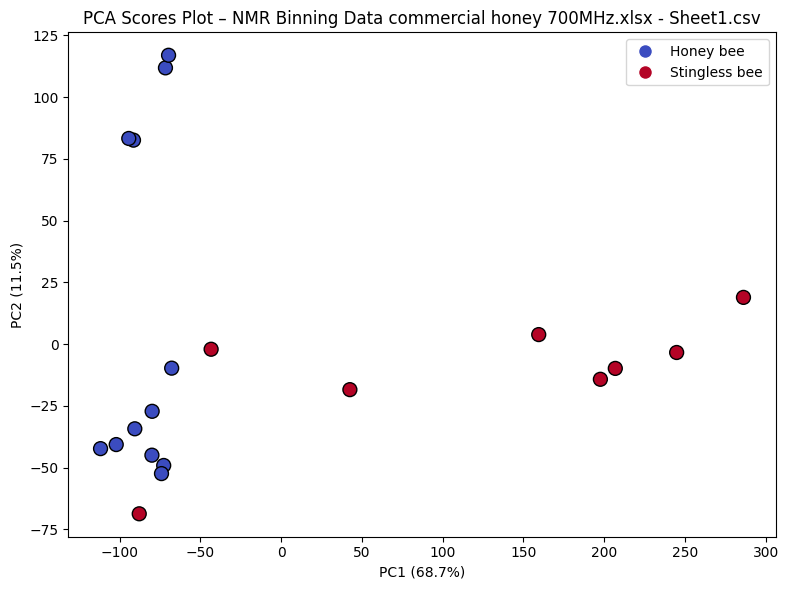

In [37]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(scores[:,0], scores[:,1], c=y_encoded, cmap='coolwarm', edgecolor='k', s=100)
plt.xlabel(f'PC1 ({var_exp[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({var_exp[1]*100:.1f}%)')
plt.title(f'PCA Scores Plot – {file_path.split("/")[-1]}')
# Create legend
handles = [
    plt.Line2D([0],[0], marker='o', color='w',
               markerfacecolor=coolwarm(0.0), markersize=10, label=le.classes_[0]),
    plt.Line2D([0],[0], marker='o', color='w',
               markerfacecolor=coolwarm(1.0), markersize=10, label=le.classes_[1])
]
plt.legend(handles=handles)
plt.tight_layout()
plt.savefig('pca_scores.png', dpi=300)
plt.show() 

**PCA Summary (700 MHz)**

- PC1 explains 68.7% of total variance; PC2 explains 11.5%
- Cumulative variance (PC1 + PC2) = 80.2%, capturing ~4/5 of 
  spectral information
- Honey bee (blue) scores negatively on PC1 (range: −115 to −50)
- Stingless bee (red) scores positively on PC1 (range: −65 to +290)
- Stingless bee samples show tighter within-group clustering than
  honey bee, suggesting greater metabolic consistency

**Outlier: H12 (Heterotrigona itama)**
- Clusters within honey bee group on PC1 (PC1 ≈ −65, PC2 ≈ −68)
- Confirmed stingless bee (H. itama) — not a labelling error
- Retained in analysis but flagged for discussion

**Hence:**
PCA of the Pareto-scaled 700 MHz binned NMR data revealed clear
separation between honey bee and stingless bee honeys along the first
principal component (PC1: 68.7%, PC2: 11.5%, cumulative: 80.2%).
Honey bee samples scored negatively on PC1 while stingless bee samples
scored positively, reflecting distinct metabolic fingerprints between
the two honey types. Stingless bee samples exhibited tighter
within-group clustering, suggesting greater metabolic consistency
compared to honey bee samples. One stingless bee sample (H12,
Heterotrigona itama) scored negatively on PC1, overlapping with the
honey bee cluster. This is consistent with the known atypical sugar
composition of H. itama honey and was retained in all analyses but
noted as a potential source of classification error in the PLS-DA model.

#### **PLS-DA with boostrap cross-validation**

- since our data is small sample and high dimensions boostrap or k-fold would be preffered to Leave one out amongst cross validation techniques

In [14]:
pls = PLSRegression(n_components=2)
n_folds = 5          # number of folds
n_repeats = 10       # number of repeats

#### **Repeated K-fold cross validation**

In [15]:
#  repeated k-fold
rkf = RepeatedKFold(n_splits=n_folds, n_repeats=n_repeats, random_state=42)

# Store accuracies and predictions
accuracies = []
all_y_true = []
all_y_pred = []

# For each split (fold and repeat)
for train_idx, test_idx in rkf.split(X_pareto):
    X_train, X_test = X_pareto[train_idx], X_pareto[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]
    
    pls = PLSRegression(n_components=2)
    pls.fit(X_train, y_train)
    y_pred_cont = pls.predict(X_test)
    y_pred_class = (y_pred_cont > 0.5).astype(int).flatten()
    
    acc = accuracy_score(y_test, y_pred_class)
    accuracies.append(acc)
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred_class)

mean_acc = np.mean(accuracies)
std_acc = np.std(accuracies)

print(f"\nRepeated {n_folds}-fold CV ({n_repeats} repeats):")
print(f"Mean accuracy = {mean_acc*100:.1f}% ± {std_acc*100:.1f}%")



Repeated 5-fold CV (10 repeats):
Mean accuracy = 89.5% ± 15.1%


#### **Overall confusion matrix (aggregated across all folds)**

Confusion matrix (aggregated):
[[113   7]
 [ 14  66]]


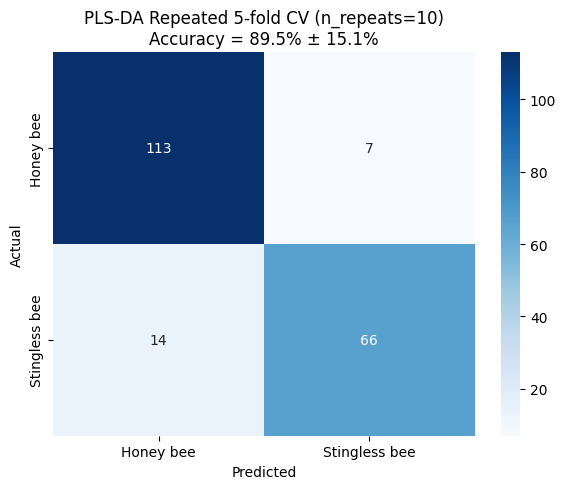

In [16]:

cm = confusion_matrix(all_y_true, all_y_pred)
print("Confusion matrix (aggregated):")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'PLS-DA Repeated {n_folds}-fold CV (n_repeats={n_repeats})\nAccuracy = {mean_acc*100:.1f}% ± {std_acc*100:.1f}%')
plt.tight_layout()
plt.savefig('plsda_confusion_kfold.png', dpi=300)
plt.show()

In [38]:

tn, fp, fn, tp = cm.ravel()
sensitivity_hb = tn / (tn + fp)   # honey bee (class 0)
sensitivity_sb = tp / (tp + fn)   # stingless bee (class 1)
print(f"Honey bee sensitivity:    {sensitivity_hb*100:.1f}%")
print(f"Stingless bee sensitivity: {sensitivity_sb*100:.1f}%")

Honey bee sensitivity:    94.2%
Stingless bee sensitivity: 82.5%


####  **BOOTSTRAP VALIDATION**

In [34]:
def bootstrap_plsda(X, y, n_bootstrap=1000 ):
    accuracies = []
    n_samples = len(y)
    for _ in range(n_bootstrap):
        train_idx = resample(range(n_samples), replace=True, n_samples=n_samples)
        test_idx = list(set(range(n_samples)) - set(train_idx))  # out-of-bag
        if len(test_idx) == 0:
            continue
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        pls = PLSRegression(n_components=2)
        pls.fit(X_train, y_train)
        y_pred_cont = pls.predict(X_test)
        y_pred_class = (y_pred_cont > 0.5).astype(int).flatten()
        acc = accuracy_score(y_test, y_pred_class)
        accuracies.append(acc)
    return np.mean(accuracies), np.std(accuracies)

mean_boot, std_boot = bootstrap_plsda(X_pareto, y_encoded, n_bootstrap=1000)
# Fix the print
print(f"\nBootstrap OOB validation (1000 iterations):")
print(f"Mean accuracy = {mean_boot*100:.1f}% ± {std_boot*100:.1f}%")


Bootstrap OOB validation (1000 iterations):
Mean accuracy = 84.2% ± 12.9%


**Summary**
- Bootstrap OOB validation provides a more stable accuracy estimate than 
  k-fold due to the small sample size (n=20), with lower variance across iterations.

In [18]:
pls.fit(X_pareto, y_encoded)
# Extract loadings for the first PLS component (most important for separation)
loadings = pls.x_loadings_[:, 0]  # shape (n_bins,)
# Get bin labels (ppm values)
bin_labels = X.columns.values  # already have from the DataFrame

#### **Variable Importance in Projection**
It measures how much each NMR bin (variable) contributes to the PLS-DA model,specifically, how much that bin helps separate the two classes (Stingless bee vs Honey bee) across all PLS components.

Mathematically it combines:
- How strongly each bin loads onto each PLS component
- How much each component explains the separation between classes

The VIP = 1.0 Threshold
VIP ValueInterpretation
- > 1.0 Bin is important: contributes more than average to class separation
- 0.8 – 1.0 Borderline: sometimes reported as secondary candidates
- < 0.8 Not important: can be ignored

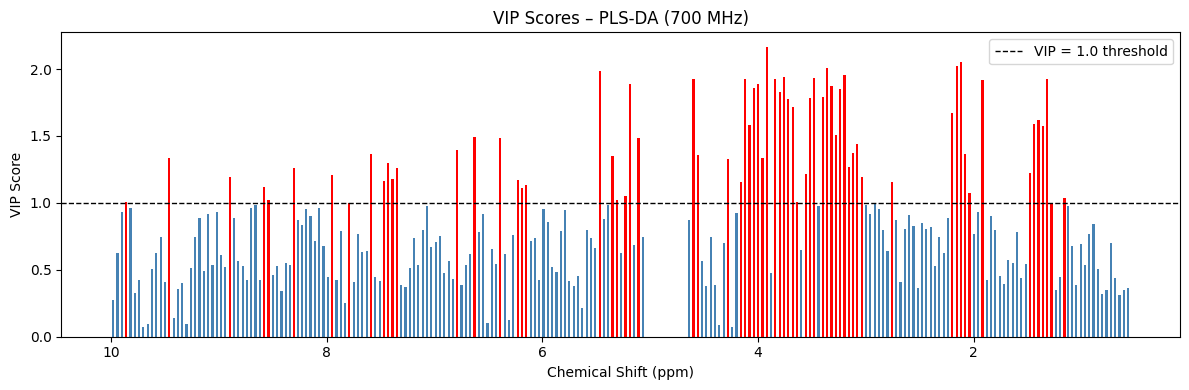

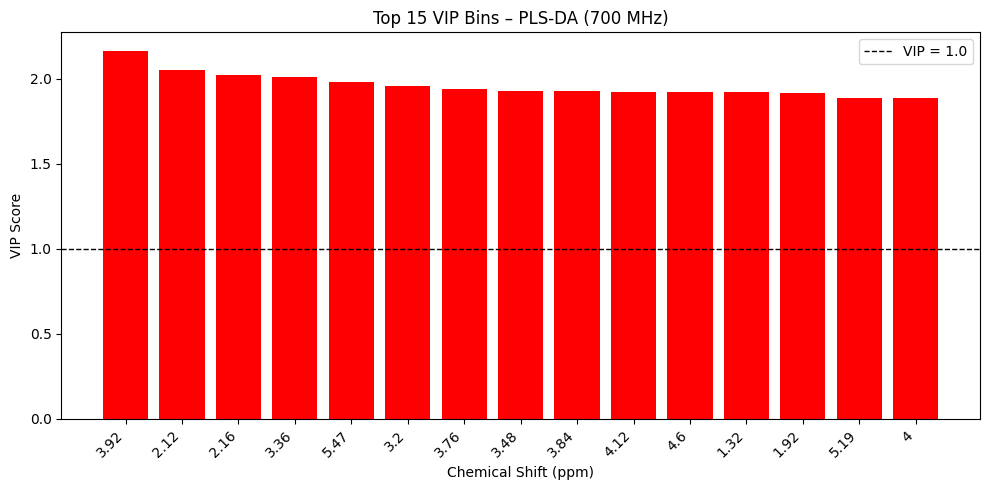


Significant bins (VIP ≥ 1.0): 68
  3.92 ppm  →  VIP = 2.166
  2.12 ppm  →  VIP = 2.054
  2.16 ppm  →  VIP = 2.021
  3.36 ppm  →  VIP = 2.011
  5.47 ppm  →  VIP = 1.982
  3.2 ppm  →  VIP = 1.959
  3.76 ppm  →  VIP = 1.943
  3.48 ppm  →  VIP = 1.931
  3.84 ppm  →  VIP = 1.927
  4.12 ppm  →  VIP = 1.925


In [32]:
def vip_scores(pls_model, X, y):
    t = pls_model.x_scores_
    w = pls_model.x_weights_
    q = pls_model.y_loadings_
    p, h = w.shape
    vips = np.zeros(p)
    s = np.diag(t.T @ t @ q.T @ q).reshape(h, -1)
    total_s = np.sum(s)
    for i in range(p):
        weight = np.array([(w[i, j] / np.linalg.norm(w[:, j]))**2 * s[j]
                           for j in range(h)])
        vips[i] = np.sqrt(p * np.sum(weight) / total_s)
    return vips

vip = vip_scores(pls, X_pareto, y_encoded)
 
plt.figure(figsize=(12, 4))
plt.bar(bin_labels.astype(float), vip,
        color=['red' if v >= 1.0 else 'steelblue' for v in vip], width=0.02)
plt.axhline(1.0, color='black', linestyle='--', linewidth=1, label='VIP = 1.0 threshold')
plt.xlabel('Chemical Shift (ppm)')
plt.ylabel('VIP Score')
plt.title('VIP Scores – PLS-DA (700 MHz)')
plt.gca().invert_xaxis()   # NMR convention: high ppm on left
plt.legend()
plt.tight_layout()
plt.savefig('vip_scores.png', dpi=300)
#  top 15 VIP bins by ppm
top_vip_idx = np.argsort(vip)[-15:][::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(15), vip[top_vip_idx],
        color=['red' if vip[i] >= 1.0 else 'steelblue' for i in top_vip_idx])
plt.xticks(range(15), bin_labels[top_vip_idx], rotation=45, ha='right')
plt.axhline(1.0, color='black', linestyle='--', linewidth=1, label='VIP = 1.0')
plt.xlabel('Chemical Shift (ppm)')
plt.ylabel('VIP Score')
plt.title('Top 15 VIP Bins – PLS-DA (700 MHz)')
plt.legend()
plt.tight_layout()
plt.savefig('vip_top15_ppm.png', dpi=300)
plt.show()

# Print significant bins (VIP > 1)
sig_bins = [(bin_labels[i], vip[i]) for i in np.where(vip >= 1.0)[0]]
print(f"\nSignificant bins (VIP ≥ 1.0): {len(sig_bins)}")
for b, v in sorted(sig_bins, key=lambda x: -x[1])[:10]:
    print(f"  {b} ppm  →  VIP = {v:.3f}")

#### **Loading Plots**

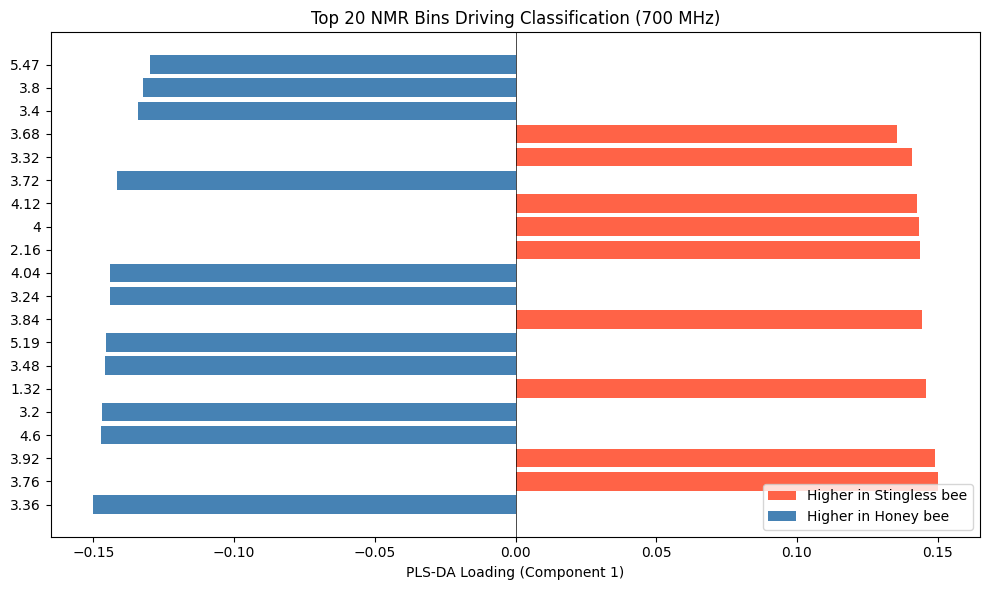


Top 10 bins with highest positive/negative loadings:
3.36: -0.1502
3.76: 0.1500
3.92: 0.1489
4.6: -0.1474
3.2: -0.1469
1.32: 0.1460
3.48: -0.1459
5.19: -0.1455
3.84: 0.1442
3.24: -0.1440


In [33]:
# Create a bar plot of top absolute loadings (e.g., top 20)
top_n = 20
abs_loadings = np.abs(loadings)
top_idx = np.argsort(abs_loadings)[-top_n:][::-1]

plt.figure(figsize=(10,6))
plt.barh(range(top_n), loadings[top_idx],
         color=['tomato' if l > 0 else 'steelblue' for l in loadings[top_idx]])
plt.yticks(range(top_n), bin_labels[top_idx])
plt.xlabel('PLS-DA Loading (Component 1)')
plt.title(f'Top {top_n} NMR Bins Driving Classification (700 MHz)')
plt.axvline(0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
legend_elements = [Patch(facecolor='tomato', label=f'Higher in {le.classes_[1]}'),
                   Patch(facecolor='steelblue', label=f'Higher in {le.classes_[0]}')]
plt.legend(handles=legend_elements, loc='lower right')
plt.savefig('plsda_loadings.png', dpi=300)
plt.show()

# Optional: print the top bins with their loadings
print("\nTop 10 bins with highest positive/negative loadings:")
for i in range(10):
    print(f"{bin_labels[top_idx[i]]}: {loadings[top_idx[i]]:.4f}")

#### **PERMUTATION TEST (accuracy) WITH PLOT**

**Note on Permutation Test Choice**

CV accuracy is used as the permutation statistic rather than Q² 
(cross-validated R²). Szymańska et al. (2012) demonstrated that 
misclassification rate and Area Under the Receiver Operating Characteristic (AUROC) are more reliable diagnostic statistics 
than Q² for two-group PLS-DA classification in metabolomics studies. 
Accuracy is directly comparable to the reported CV and bootstrap results 
above, keeping all validation metrics consistent.

**References**
Primary (2008):
Westerhuis JA, Hoefsloot HCJ, Smit S, Vis DJ, Smilde AK, van Velzen EJJ, van Duijnhoven JPM, van Dorsten FA. Assessment of PLSDA cross validation. Metabolomics (2008) 4:81–89.
https://link.springer.com/article/10.1007/s11306-007-0099-6

Follow-up (2012)  :
Szymańska E, Saccenti E, Smilde AK, Westerhuis JA. Double-check: validation of diagnostic statistics for PLS-DA models in metabolomics studies. Metabolomics (2012) 8(Suppl 1):S3–S16.
https://pmc.ncbi.nlm.nih.gov/articles/PMC3337399/

Real model CV Accuracy = 0.8500
Running permutation test (500 iterations)...
  100/500 done
  200/500 done
  300/500 done
  400/500 done
  500/500 done

Permutation test p-value (Accuracy) = 0.0040


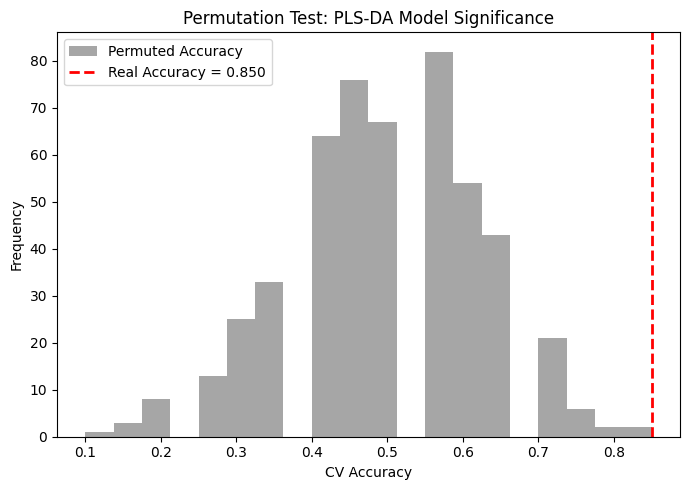

=> Model is statistically significant (p = 0.0040)


In [21]:
# ── PERMUTATION TEST (Accuracy-based) ──────────────────────────────────────

def calculate_accuracy(X, y, n_components=2, n_folds=5):
    """Calculate CV accuracy using standard KFold."""
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    y_pred_all = np.zeros_like(y, dtype=float)
    for train_idx, test_idx in kf.split(X):
        pls = PLSRegression(n_components=n_components)
        pls.fit(X[train_idx], y[train_idx])
        y_pred_all[test_idx] = pls.predict(X[test_idx]).flatten()
    y_class = (y_pred_all > 0.5).astype(int)
    return accuracy_score(y, y_class)

# Real model accuracy
real_acc = calculate_accuracy(X_pareto, y_encoded)
print(f"Real model CV Accuracy = {real_acc:.4f}")

# Permutation test (shuffle labels)
n_perm = 500
perm_accs = []
print(f"Running permutation test ({n_perm} iterations)...")
for i in range(n_perm):
    y_perm = np.random.permutation(y_encoded)
    perm_accs.append(calculate_accuracy(X_pareto, y_perm))
    if (i+1) % 100 == 0:
        print(f"  {i+1}/{n_perm} done")

# p-value: proportion of permuted accuracies >= real accuracy
p_value = np.mean(np.array(perm_accs) >= real_acc)
print(f"\nPermutation test p-value (Accuracy) = {p_value:.4f}")

# Plot
plt.figure(figsize=(7, 5))
plt.hist(perm_accs, bins=20, color='gray', alpha=0.7, label='Permuted Accuracy')
plt.axvline(real_acc, color='red', linestyle='--', linewidth=2,
            label=f'Real Accuracy = {real_acc:.3f}')
plt.xlabel('CV Accuracy')
plt.ylabel('Frequency')
plt.title('Permutation Test: PLS-DA Model Significance')
plt.legend()
plt.tight_layout()
plt.savefig('permutation_accuracy.png', dpi=300)
plt.show()

if p_value < 0.05:
    print(f"=> Model is statistically significant (p = {p_value:.4f})")
else:
    print(f"=> Model is NOT statistically significant (p = {p_value:.4f})")